## Import Libraries

In [1]:
# Environment-neutral imports and project configuration
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd

DATA_CANDIDATES = [Path('data/Spotify_data.csv'), Path('../data/Spotify_data.csv')]
DATA_PATH = next((candidate for candidate in DATA_CANDIDATES if candidate.exists()), DATA_CANDIDATES[0])
USE_FULL_DATA = True
RANDOM_SEED = 11
SMOKE_TEST_LIMIT = None  # Set to a small number, such as 5000, for quick local smoke runs.
ENABLE_GRID_SEARCH = False  # Full-data cross-validation is expensive; enable only on a capable machine.


##Load Dataset

In [2]:
# Validate dataset path before starting the Spark workflow
print('Checking dataset path...')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH.resolve()}')
print(f'Dataset found: {DATA_PATH.resolve()}')


Checking dataset path...
Dataset found: C:\Users\SampathNagaMaddineni\Documents\UNT\IBD\Project\main\data\Spotify_data.csv


##Install PySpark

In [3]:
# Optional Colab setup. Local Jupyter users should install requirements.txt instead.
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Colab detected. Installing PySpark if needed...')
    %pip install -q pyspark
else:
    print('Local Jupyter detected. Using installed dependencies from requirements.txt.')


Local Jupyter detected. Using installed dependencies from requirements.txt.


## Import Libraries and Initialize Spark

In [4]:
# Import Spark libraries and initialize a local Spark session
from pyspark.sql import SparkSession
from pyspark.sql import functions as fn
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import PCA, StandardScaler, VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.sql.types import FloatType

import matplotlib.pyplot as plt
import seaborn as sns

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

spark = (
    SparkSession.builder
    .appName('MusicDataAnalysisRecommendation')
    .master('local[*]')
    .config('spark.driver.memory', '4g')
    .config('spark.sql.shuffle.partitions', '8')
    .config('spark.pyspark.python', sys.executable)
    .config('spark.pyspark.driver.python', sys.executable)
    .getOrCreate()
)

raw_spark_df = (
    spark.read
    .option('header', True)
    .option('inferSchema', True)
    .csv(str(DATA_PATH))
)

if SMOKE_TEST_LIMIT:
    raw_spark_df = raw_spark_df.limit(SMOKE_TEST_LIMIT)

raw_spark_df = raw_spark_df.cache()
print(f'Loaded rows with Spark: {raw_spark_df.count():,}')
print(f'Columns: {len(raw_spark_df.columns)}')
raw_spark_df.printSchema()


Loaded rows with Spark: 169,909
Columns: 19
root
 |-- acousticness: double (nullable = true)
 |-- artists: string (nullable = true)
 |-- danceability: string (nullable = true)
 |-- duration_ms: string (nullable = true)
 |-- energy: string (nullable = true)
 |-- explicit: string (nullable = true)
 |-- id: string (nullable = true)
 |-- instrumentalness: string (nullable = true)
 |-- key: string (nullable = true)
 |-- liveness: string (nullable = true)
 |-- loudness: string (nullable = true)
 |-- mode: string (nullable = true)
 |-- name: string (nullable = true)
 |-- popularity: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- speechiness: string (nullable = true)
 |-- tempo: string (nullable = true)
 |-- valence: string (nullable = true)
 |-- year: string (nullable = true)



##Data Loading and Preprocessing

In [5]:
# Build the main Spark DataFrame. Full data is the default for this Big Data project.
numeric_columns = [
    'acousticness', 'danceability', 'duration_ms', 'energy', 'explicit',
    'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'popularity',
    'speechiness', 'tempo', 'valence', 'year'
]

clean_spark_df = raw_spark_df
for column_name in numeric_columns:
    clean_spark_df = clean_spark_df.withColumn(column_name, fn.col(column_name).cast('double'))

base_spark_df = clean_spark_df if USE_FULL_DATA else clean_spark_df.filter(fn.col('year') >= 2015)
raw_modeling_rows = base_spark_df.count()
base_spark_df = base_spark_df.dropna(subset=numeric_columns).cache()
print(f'Dropped rows with invalid numeric values: {raw_modeling_rows - base_spark_df.count():,}')
music_df = base_spark_df.drop('id').cache()
music_with_id_df = base_spark_df.cache()

# Keep a recent-years Pandas slice only for comparison plots and lightweight local visuals.
music_2015_2020 = clean_spark_df.filter(fn.col('year') >= 2015).drop('id').toPandas()
raw_data = clean_spark_df.toPandas()
for column_name in numeric_columns:
    if column_name in music_2015_2020.columns:
        music_2015_2020[column_name] = pd.to_numeric(music_2015_2020[column_name], errors='coerce')
    if column_name in raw_data.columns:
        raw_data[column_name] = pd.to_numeric(raw_data[column_name], errors='coerce')

print(f'Main modeling rows: {music_df.count():,}')
print(f'Recent-years comparison rows: {len(music_2015_2020):,}')


Dropped rows with invalid numeric values: 1,447


Main modeling rows: 168,462
Recent-years comparison rows: 11,639


##Data Exploration

In [6]:
# Check data types
print("Data Types:")
print(music_df.dtypes)

# Show basic statistics
print("Descriptive Statistics:")
music_df.describe().show()


Data Types:
[('acousticness', 'double'), ('artists', 'string'), ('danceability', 'double'), ('duration_ms', 'double'), ('energy', 'double'), ('explicit', 'double'), ('instrumentalness', 'double'), ('key', 'double'), ('liveness', 'double'), ('loudness', 'double'), ('mode', 'double'), ('name', 'string'), ('popularity', 'double'), ('release_date', 'string'), ('speechiness', 'double'), ('tempo', 'double'), ('valence', 'double'), ('year', 'double')]
Descriptive Statistics:


+-------+-------------------+--------------------+-------------------+------------------+------------------+-------------------+-------------------+-----------------+-------------------+------------------+------------------+----------------------------+------------------+------------------+-------------------+------------------+------------------+-----------------+
|summary|       acousticness|             artists|       danceability|       duration_ms|            energy|           explicit|   instrumentalness|              key|           liveness|          loudness|              mode|                        name|        popularity|      release_date|        speechiness|             tempo|           valence|             year|
+-------+-------------------+--------------------+-------------------+------------------+------------------+-------------------+-------------------+-----------------+-------------------+------------------+------------------+----------------------------+-----------

In [7]:
# Convert to Pandas DataFrame for correlation and covariance
music_pd = music_df.toPandas()

# Convert all numeric columns to proper numeric types
for col in music_pd.select_dtypes(include=['object']).columns:
    music_pd[col] = pd.to_numeric(music_pd[col], errors='coerce')

# Drop columns with all NaN values after conversion
music_pd = music_pd.dropna(axis=1, how='all')


In [8]:

# Correlation matrix
print("Correlation Matrix:")
print(music_pd.corr())

# Covariance matrix
print("Covariance Matrix:")
print(music_pd.cov())


Correlation Matrix:


                  acousticness  danceability  duration_ms    energy  explicit  \
acousticness          1.000000     -0.259177    -0.081448 -0.748602 -0.252450   
danceability         -0.259177      1.000000    -0.133288  0.213590  0.241002   
duration_ms          -0.081448     -0.133288     1.000000  0.037983 -0.044263   
energy               -0.748602      0.213590     0.037983  1.000000  0.141044   
explicit             -0.252450      0.241002    -0.044263  0.141044  1.000000   
instrumentalness      0.338739     -0.282069     0.083818 -0.290141 -0.138674   
key                  -0.021034      0.022474    -0.003161  0.029583  0.008628   
liveness             -0.025889     -0.105581     0.035964  0.128501  0.040116   
loudness             -0.565109      0.288289    -0.014777  0.782198  0.151303   
mode                  0.046057     -0.045178    -0.048125 -0.037978 -0.083229   
name                 -0.070259     -0.145591    -0.237897 -0.070383 -0.052666   
popularity           -0.5897

                  acousticness  danceability   duration_ms        energy  \
acousticness      1.414272e-01 -1.703626e-02 -3.696746e+03 -7.517160e-02   
danceability     -1.703626e-02  3.055080e-02 -2.811734e+03  9.968492e-03   
duration_ms      -3.696746e+03 -2.811734e+03  1.456605e+10  1.224032e+03   
energy           -7.517160e-02  9.968492e-03  1.224032e+03  7.129727e-02   
explicit         -2.652749e-02  1.177030e-02 -1.492668e+03  1.052316e-02   
instrumentalness  3.939885e-02 -1.524818e-02  3.128661e+03 -2.396059e-02   
key              -2.780752e-02  1.380945e-02 -1.341074e+03  2.776889e-02   
liveness         -1.720178e-03 -3.260520e-03  7.668858e+02  6.062223e-03   
loudness         -1.199147e+00  2.843237e-01 -1.006278e+04  1.178493e+00   
mode              7.872821e-03 -3.589274e-03 -2.640051e+03 -4.609278e-03   
name             -1.195355e+09 -1.478124e+09 -9.850895e+14 -8.718464e+08   
popularity       -4.773903e+00  8.060257e-01  1.687417e+05  2.837350e+00   
release_date

In [9]:

# Check for null values in the PySpark DataFrame
from pyspark.sql.functions import col, count, when, isnull, isnan

print("Null Values Count:")
music_df.select([count(when(isnull(c), c)).alias(c) for c in music_df.columns]).show()

print("NaN Values Count:")
music_df.select([count(when(isnan(col(c)), c)).alias(c) for c in music_df.columns]).show()


Null Values Count:


+------------+-------+------------+-----------+------+--------+----------------+---+--------+--------+----+----+----------+------------+-----------+-----+-------+----+
|acousticness|artists|danceability|duration_ms|energy|explicit|instrumentalness|key|liveness|loudness|mode|name|popularity|release_date|speechiness|tempo|valence|year|
+------------+-------+------------+-----------+------+--------+----------------+---+--------+--------+----+----+----------+------------+-----------+-----+-------+----+
|           0|      0|           0|          0|     0|       0|               0|  0|       0|       0|   0|   0|         0|           0|          0|    0|      0|   0|
+------------+-------+------------+-----------+------+--------+----------------+---+--------+--------+----+----+----------+------------+-----------+-----+-------+----+

NaN Values Count:


+------------+-------+------------+-----------+------+--------+----------------+---+--------+--------+----+----+----------+------------+-----------+-----+-------+----+
|acousticness|artists|danceability|duration_ms|energy|explicit|instrumentalness|key|liveness|loudness|mode|name|popularity|release_date|speechiness|tempo|valence|year|
+------------+-------+------------+-----------+------+--------+----------------+---+--------+--------+----+----+----------+------------+-----------+-----+-------+----+
|           0|      0|           0|          0|     0|       0|               0|  0|       0|       0|   0|   0|         0|           0|          0|    0|      0|   0|
+------------+-------+------------+-----------+------+--------+----------------+---+--------+--------+----+----+----------+------------+-----------+-----+-------+----+



##Pair Plot Visualiz

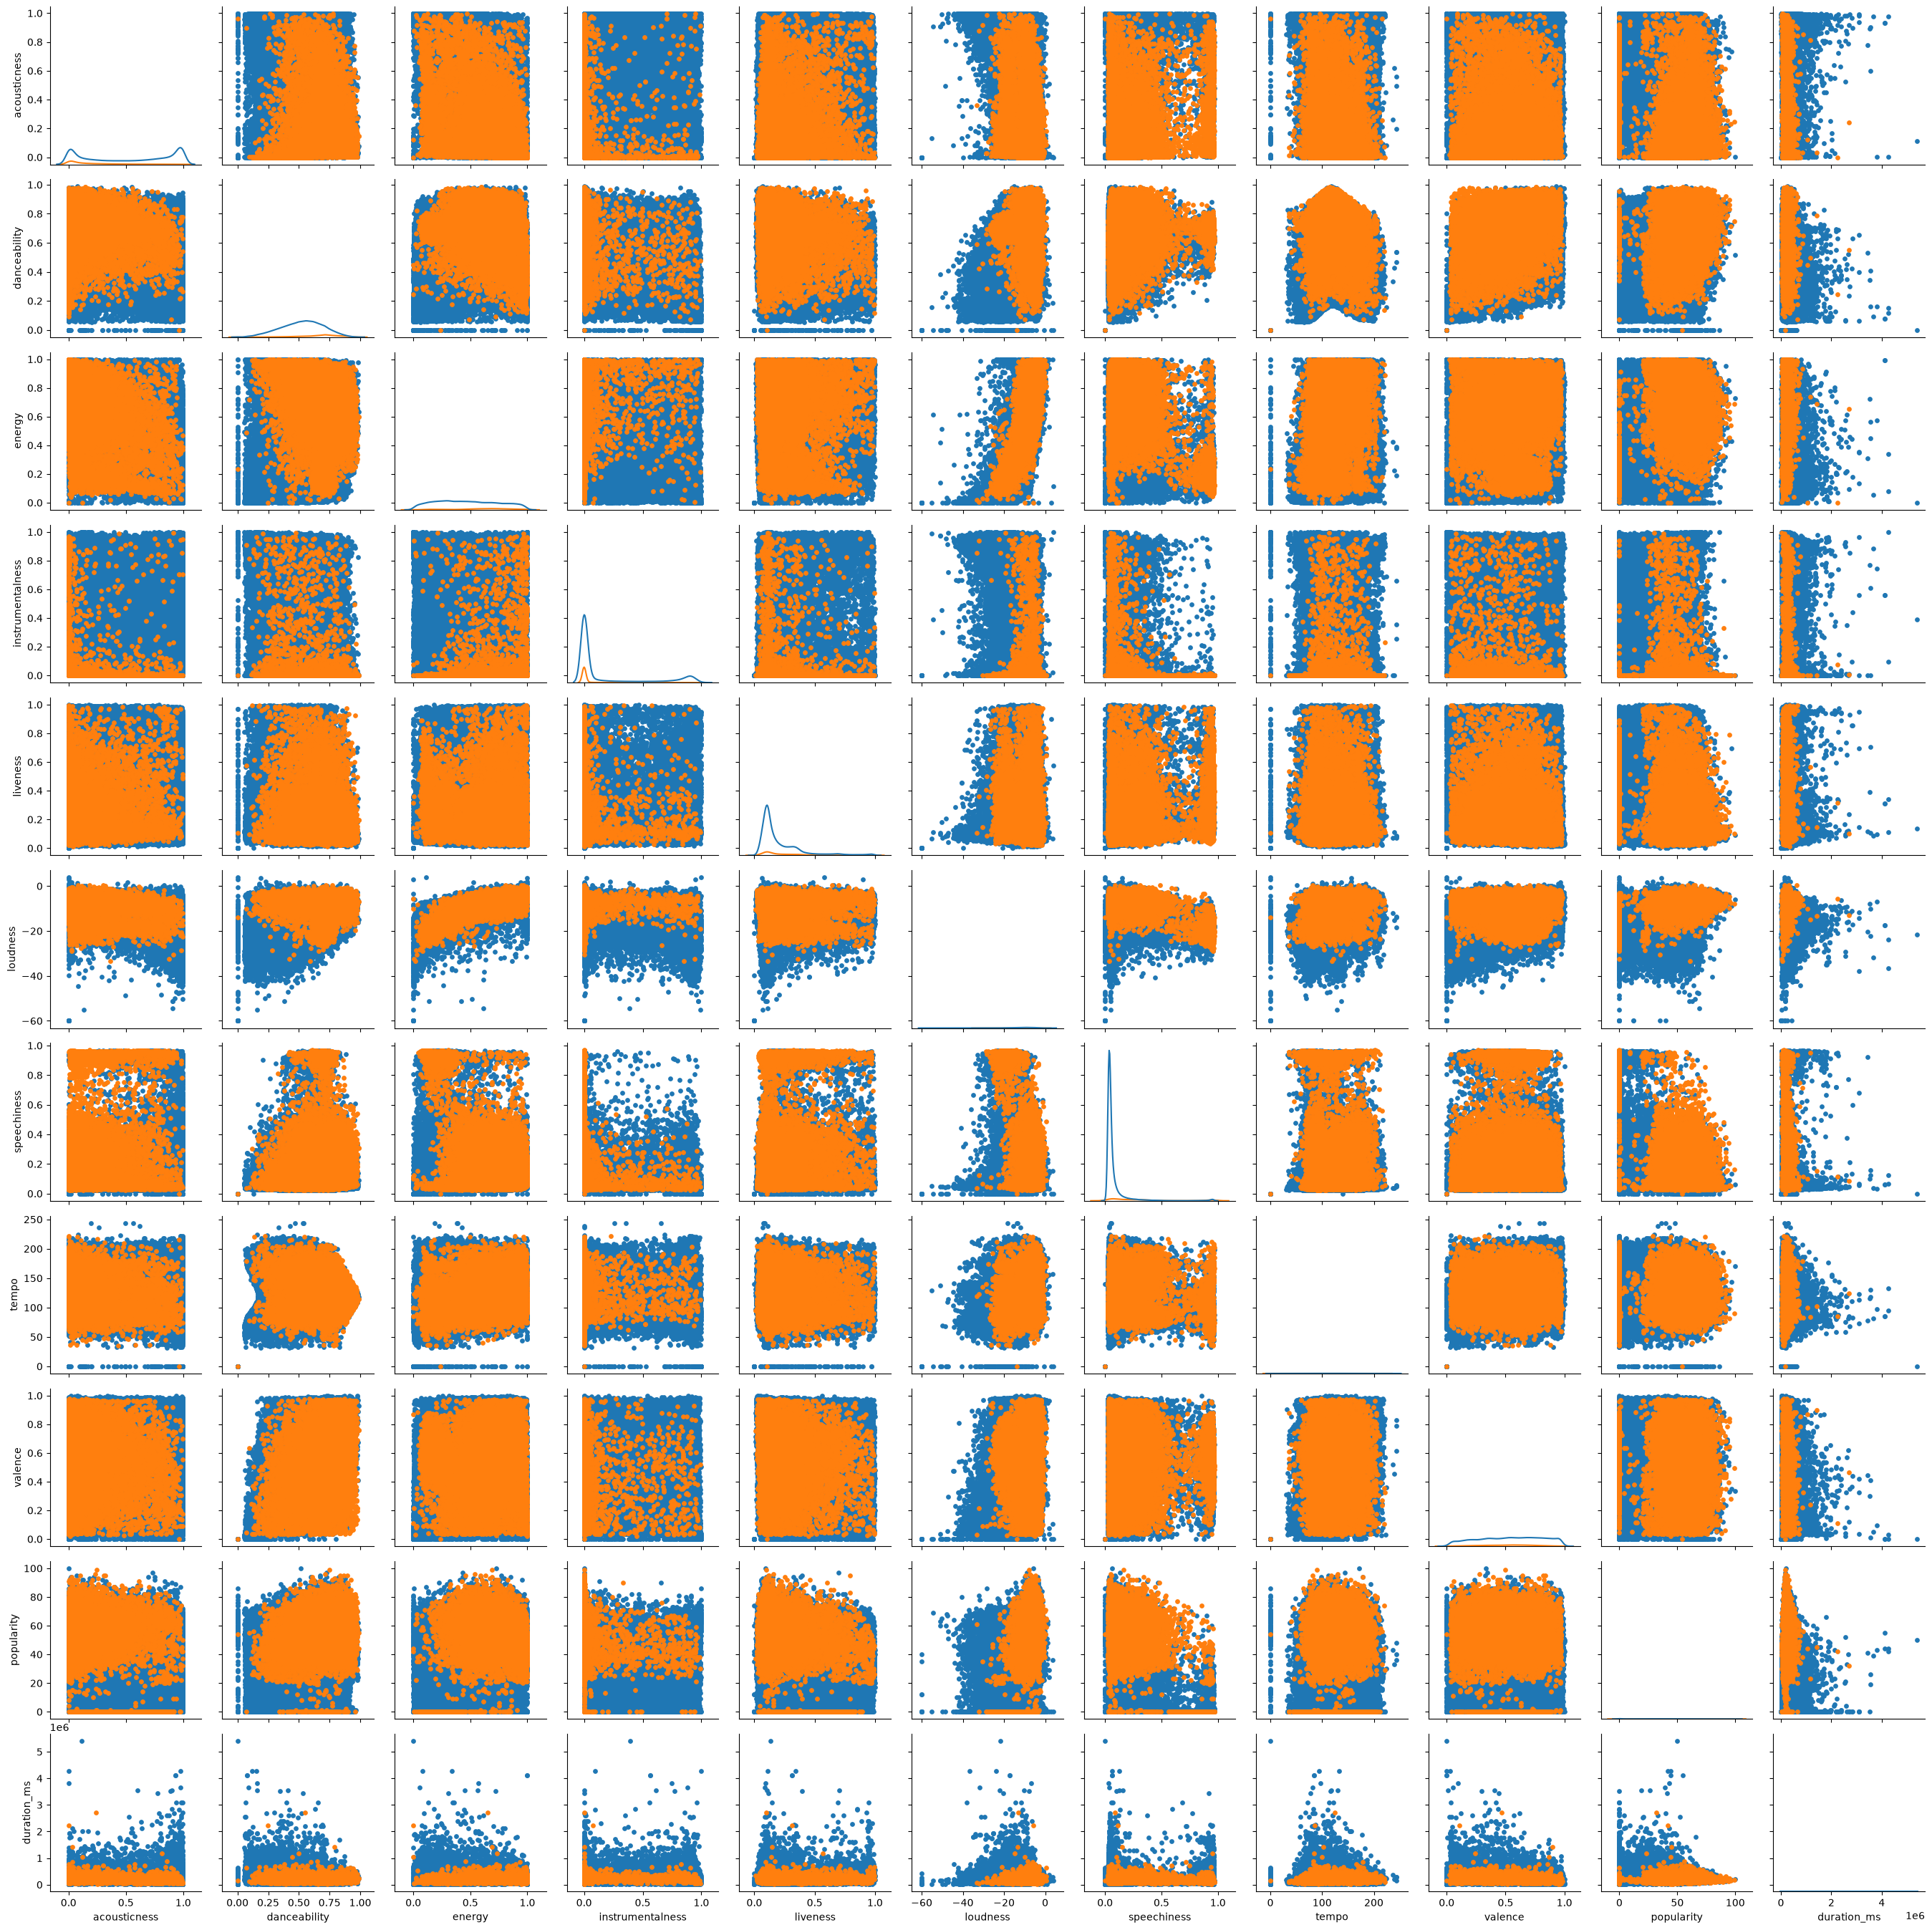

In [10]:
# Pair Grid Visualization
p = sns.PairGrid(music_pd, vars=['acousticness', 'danceability', 'energy',
                                 'instrumentalness', 'liveness', 'loudness',
                                 'speechiness', 'tempo', 'valence', 'popularity',
                                 'duration_ms'], hue='explicit')
p.map_diag(sns.kdeplot)  # Kernel density on diagonal
p.map_offdiag(plt.scatter, s=15)  # Scatter plot on off-diagonal


##Popularity Distribution Visualization

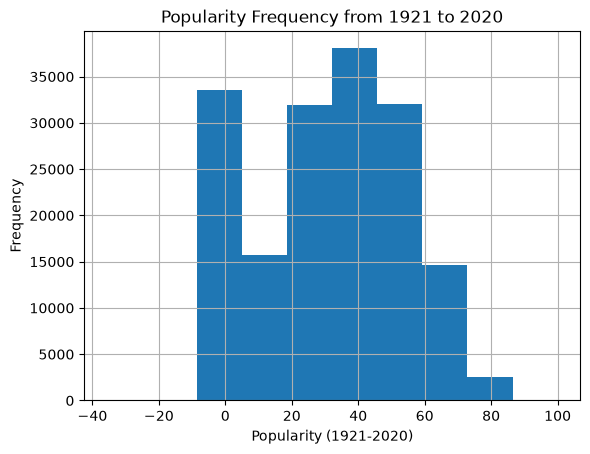

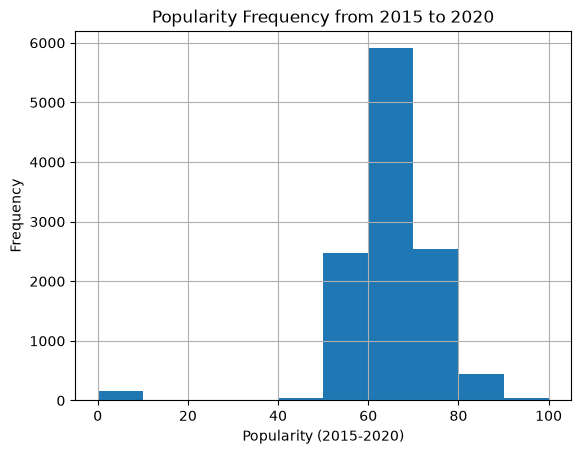

In [11]:
# Popularity distribution from the original data (1921 - 2020)
raw_data['popularity'].hist()
plt.xlabel('Popularity (1921-2020)')
plt.ylabel('Frequency')
plt.title('Popularity Frequency from 1921 to 2020')
plt.show()

# Popularity distribution from the recent data (2015 - 2020)
music_2015_2020['popularity'].hist()
plt.xlabel('Popularity (2015-2020)')
plt.ylabel('Frequency')
plt.title('Popularity Frequency from 2015 to 2020')
plt.show()


##Annual Trend Analysis

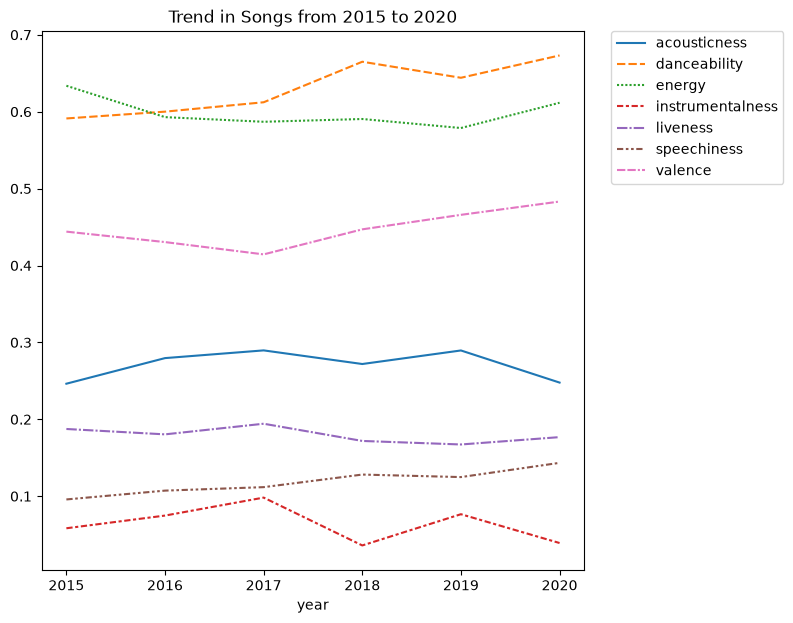

In [12]:
# Isolate numeric columns for analysis
music_num = music_2015_2020.drop(['artists', 'explicit', 'mode', 'name',
                                  'release_date', 'key'], axis=1)

# Analyze trends by year
year_trend = music_num.groupby('year').mean().drop(['duration_ms', 'tempo',
                                                    'popularity', 'loudness'], axis=1)

# Plot yearly trend
plt.figure(figsize=(7, 7))
sns.lineplot(data=year_trend)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('Trend in Songs from 2015 to 2020')
plt.show()


##Popularity vs Other Features

C:\Users\SampathNagaMaddineni\AppData\Local\Temp\ipykernel_26340\967460485.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


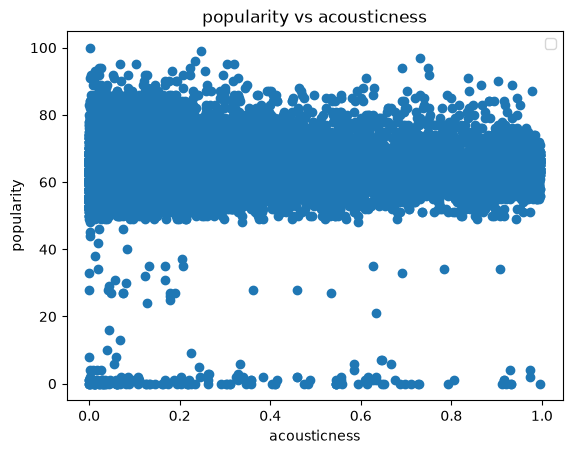

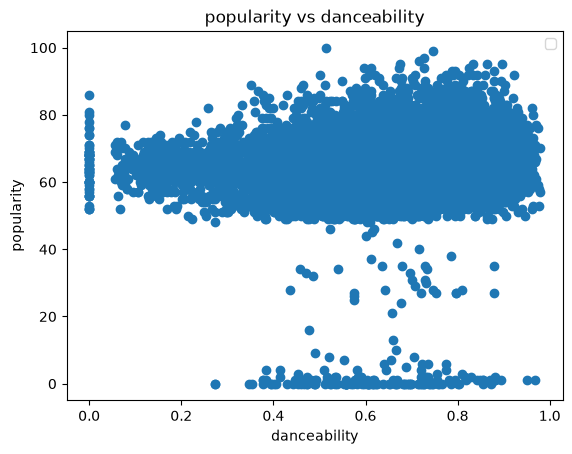

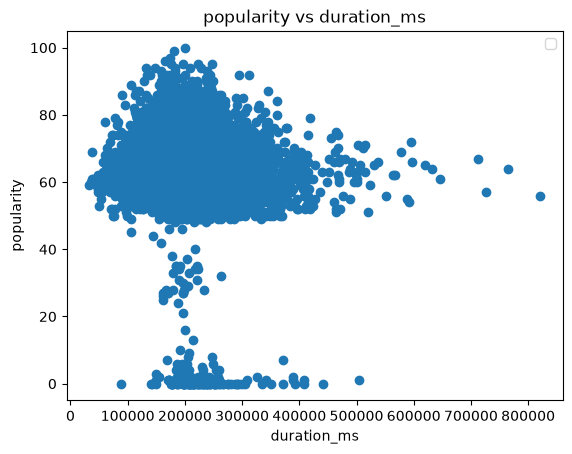

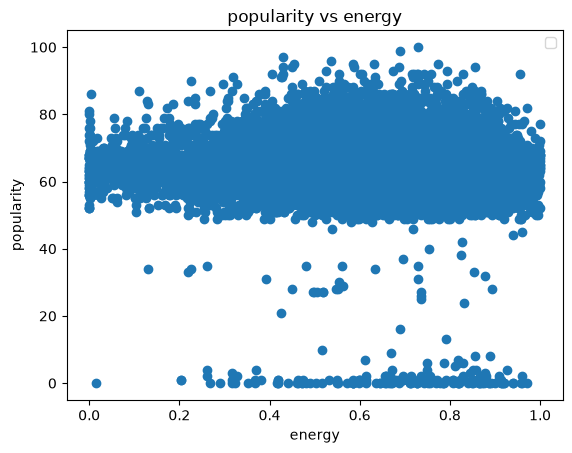

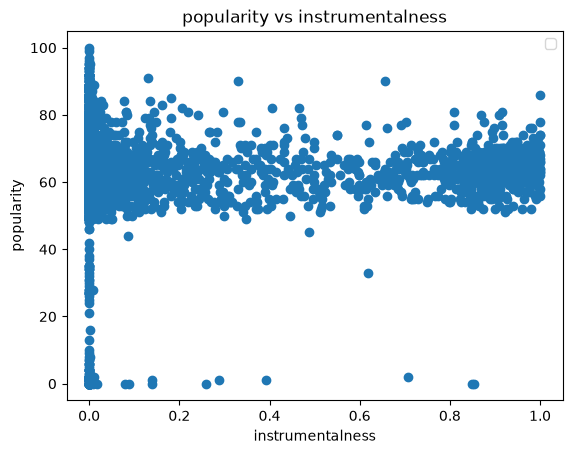

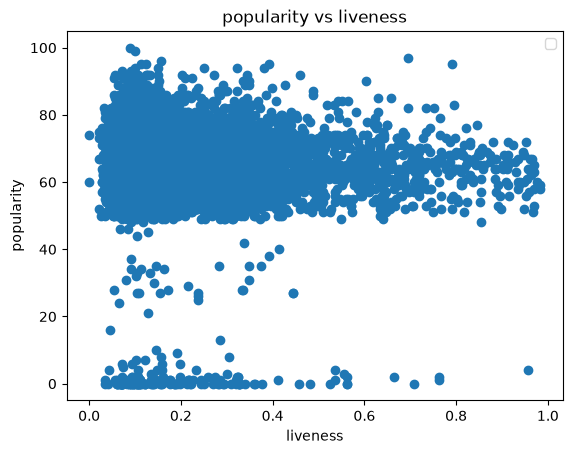

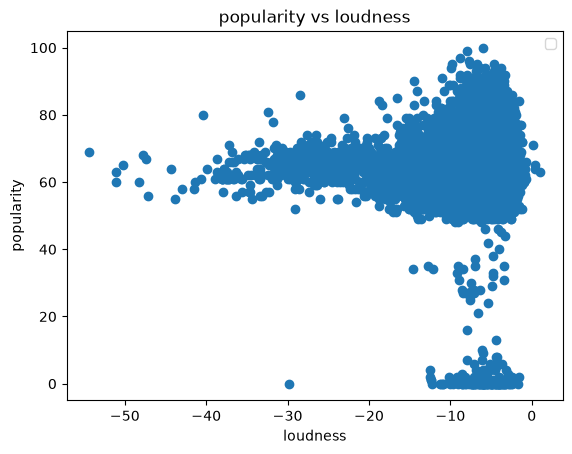

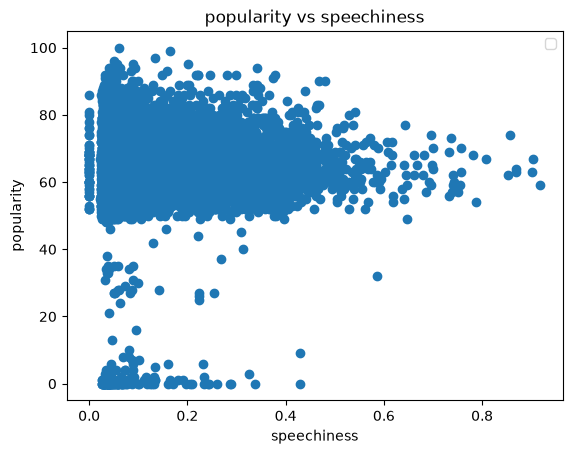

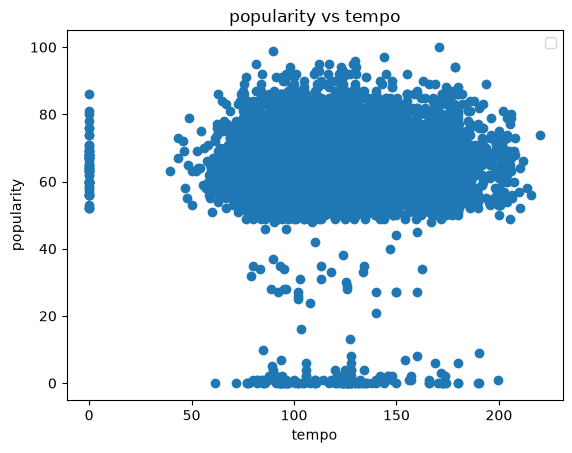

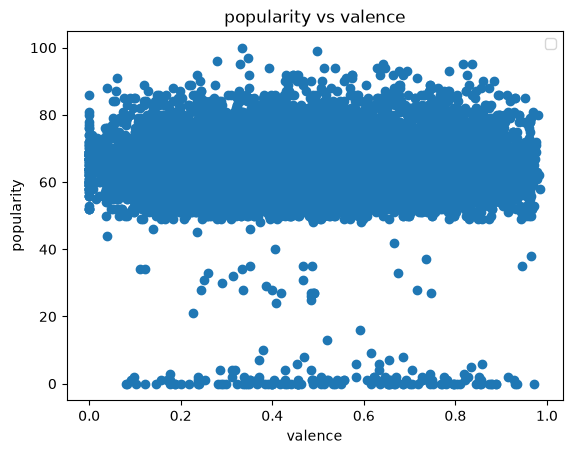

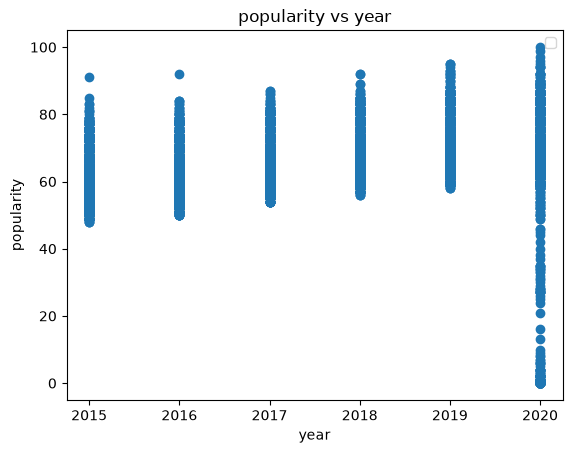

In [13]:
# Plot popularity against all other features
y_col = 'popularity'
x_columns = music_num.columns.drop('popularity')

for x_col in x_columns:
    plt.figure()
    ax = plt.gca()
    ax.scatter(music_num[x_col], music_num[y_col])
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{y_col} vs {x_col}")
    plt.legend()
    plt.show()


##Data Preparation for Linear Regression

In [14]:
# Assemble and scale regression features with a Spark ML pipeline
regression_features = ['danceability', 'energy', 'loudness', 'explicit', 'key']
regression_feature_pipe = Pipeline(stages=[
    VectorAssembler(inputCols=regression_features, outputCol='regression_features', handleInvalid='skip'),
    StandardScaler(withMean=True, withStd=True, inputCol='regression_features', outputCol='features'),
])

regression_feature_model = regression_feature_pipe.fit(music_df)
music_df_xformed = regression_feature_model.transform(music_df).cache()

train, test, val = music_df_xformed.randomSplit([0.7, 0.2, 0.1], seed=RANDOM_SEED)
print(f'Train rows: {train.count():,}, test rows: {test.count():,}, validation rows: {val.count():,}')


Train rows: 117,861, test rows: 33,703, validation rows: 16,898


## Linear Regression - Model Training and Evaluation

In [15]:
# Linear Regression baseline
linear_reg = LinearRegression(featuresCol='features', labelCol='popularity')
model1 = linear_reg.fit(train)
model1_output = model1.transform(train)
model1_evaluator = RegressionEvaluator(predictionCol='prediction', metricName='mse', labelCol='popularity')

print('Coefficients: ' + str(model1.coefficients))
print('Intercept: ' + str(model1.intercept))
print('RMSE of Linear Regression Model: %f' % model1.summary.rootMeanSquaredError)

lr_mse = model1_evaluator.evaluate(model1.transform(test))
print('Linear Regression MSE:', lr_mse)
print('Training MSE value:', model1_evaluator.evaluate(model1_output))
print('Testing MSE value:', lr_mse)

model1_output.select('prediction', 'popularity', 'features').show(5)


Coefficients: [1.4274870359445866,7.1371536265253726,3.6253695347632244,2.6780707464438755,-0.11078057542444593]
Intercept: 31.723753367363344
RMSE of Linear Regression Model: 18.226444


Linear Regression MSE: 331.37683883263537


Training MSE value: 332.2032734435935
Testing MSE value: 331.37683883263537


+------------------+----------+--------------------+
|        prediction|popularity|            features|
+------------------+----------+--------------------+
| 16.91356467614879|      63.0|[-1.8845586746802...|
|33.738727743786555|      63.0|[-2.1134075060700...|
|11.867256428521898|      63.0|[-3.0860150394767...|
| 40.61037102412756|      39.0|[-0.9920482322599...|
|  45.1341787020514|      49.0|[-1.2666668299277...|
+------------------+----------+--------------------+
only showing top 5 rows



##Random Forest - Model Training and Evaluation

In [16]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.feature import VectorIndexer
from pyspark.ml.evaluation import RegressionEvaluator

# Feature indexing
feature_indexer = VectorIndexer(inputCol="features", outputCol="indexedFeatures", maxCategories=4).fit(music_df_xformed)

# Initialize Random Forest
rf = RandomForestRegressor(featuresCol="indexedFeatures", labelCol="popularity")
pipeline = Pipeline(stages=[feature_indexer, rf])

# Train Random Forest model
rf_model = pipeline.fit(train)
predictions = rf_model.transform(test)

# Evaluate using MSE
evaluator = RegressionEvaluator(labelCol="popularity", predictionCol="prediction", metricName="mse")
rf_mse = evaluator.evaluate(predictions)
print("MSE on test data = %g" % rf_mse)

# Evaluate Random Forest on the test set
rf_mse = evaluator.evaluate(predictions)  # Store Random Forest MSE
print("Random Forest MSE:", rf_mse)


# Show sample predictions
predictions.select("prediction", "popularity", "features").show(5)

# Extract the trained Random Forest model
rf_trained_model = rf_model.stages[1]
print(rf_trained_model)


MSE on test data = 298.269


Random Forest MSE: 298.26902509168036


+------------------+----------+--------------------+
|        prediction|popularity|            features|
+------------------+----------+--------------------+
| 36.86855383427552|      45.0|[-1.4554671158243...|
| 39.33628472135509|      35.0|[-2.1362923892090...|
|34.651192179321015|      44.0|[-1.8330676876175...|
| 32.54744866609975|      31.0|[-1.8502313499717...|
| 45.34870428881716|      40.0|[-1.2323395052192...|
+------------------+----------+--------------------+
only showing top 5 rows

RandomForestRegressionModel: uid=RandomForestRegressor_ca0d252fa0f1, numTrees=20, numFeatures=5


##Hyperparameter Tuning for Random Forest (Optional)

In [17]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
enable_grid_search = ENABLE_GRID_SEARCH
if enable_grid_search:
    # Hyperparameter tuning for Random Forest
    param_grid = ParamGridBuilder() \
        .addGrid(rf.numTrees, [10, 30, 50]) \
        .addGrid(rf.maxDepth, [5, 15, 25]) \
        .build()

    evaluator = RegressionEvaluator(labelCol='popularity', predictionCol='prediction', metricName='rmse')
    cv = CrossValidator(estimator=pipeline, estimatorParamMaps=param_grid, evaluator=evaluator, numFolds=2)

    # Cross-validation model
    cv_model = cv.fit(train)
    best_rf_model = cv_model.bestModel.stages[1]

    # Report best parameters
    print("Best number of trees: ", best_rf_model.getNumTrees)
    print("Best max depth: ", best_rf_model.getOrDefault('maxDepth'))

if not enable_grid_search:
    print('Grid search skipped. Set ENABLE_GRID_SEARCH = True in the config cell to run full-data cross-validation.')


Grid search skipped. Set ENABLE_GRID_SEARCH = True in the config cell to run full-data cross-validation.


##Final Random Forest Model with Best Parameters

In [18]:
# Best Random Forest model with tuned parameters
final_rf = RandomForestRegressor(featuresCol='features', labelCol='popularity', numTrees=50, maxDepth=5)
final_pipe = Pipeline(stages=[feature_indexer, final_rf])

# Train the model
final_rf_model = final_pipe.fit(train)

# Evaluate the final model
train_predictions = final_rf_model.transform(train)
test_predictions = final_rf_model.transform(test)

evaluator1 = RegressionEvaluator(labelCol='popularity', predictionCol='prediction', metricName="mse")
print("Training MSE: ", evaluator1.evaluate(train_predictions))
print("Testing MSE: ", evaluator1.evaluate(test_predictions))

# Feature importance
feature_importances = final_rf_model.stages[-1].featureImportances.toArray()
features = ['danceability', 'energy', 'loudness', 'explicit', 'key']
feature_scoring = pd.DataFrame(list(zip(features, feature_importances)),
                               columns=['feature_name', 'importance_score']).sort_values(by='importance_score', ascending=False)

print("Feature Importance:")
display(feature_scoring)


Training MSE:  299.47734149652564


Testing MSE:  298.84040918069934
Feature Importance:


,feature_name,importance_score
2,loudness,0.465238
1,energy,0.405522
3,explicit,0.089672
0,danceability,0.038471
4,key,0.001098


##Model Comparison

In [19]:
# Compare Linear Regression and Random Forest models
compare_dict = {
    'model_name': ['Linear Regression', 'Random Forest'],
    'mse': [lr_mse, rf_mse],
    'rmse': [np.sqrt(lr_mse), np.sqrt(rf_mse)]
}

compare_df = pd.DataFrame.from_dict(compare_dict)
print("Model Comparison:")
display(compare_df)


Model Comparison:


,model_name,mse,rmse
0,Linear Regression,331.376839,18.203759
1,Random Forest,298.269025,17.270467


##PCA (Principal Component Analysis)
##PCA Pipeline Definition and Scree Plot

In [20]:
# PCA pipeline on scaled Spark features
pca_features = [
    'acousticness', 'danceability', 'energy', 'explicit', 'instrumentalness',
    'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'valence', 'year'
]

music_pipe = Pipeline(stages=[
    VectorAssembler(inputCols=pca_features, outputCol='audio_features', handleInvalid='skip'),
    StandardScaler(withMean=True, withStd=True, inputCol='audio_features', outputCol='scaled_audio_features'),
    PCA(k=13, inputCol='scaled_audio_features', outputCol='pca_score')
])

music_model = music_pipe.fit(music_with_id_df)
music_pca = music_model.transform(music_with_id_df).cache()
music_pca.select('id', 'name', 'artists', 'scaled_audio_features', 'pca_score').show(5, truncate=False)


+----------------------+---------------------------------------------+----------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|id                    |name                                         |artists                                 |scaled_audio_features                                                                                                                                                                                                                                            

Sum of Explained Variance: 1.0


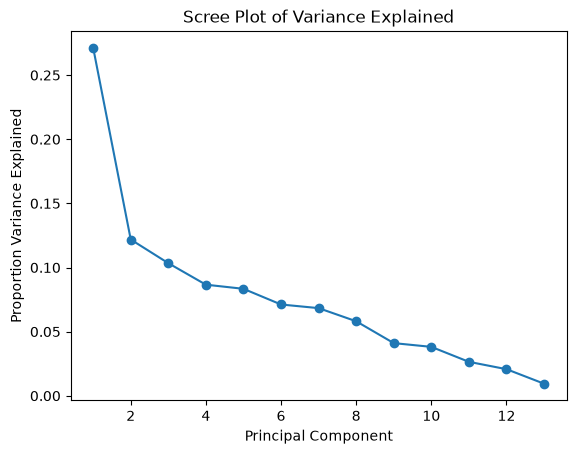

In [21]:
# Explained variance
explained_var = music_model.stages[-1].explainedVariance
print("Sum of Explained Variance:", sum(explained_var))

# Scree Plot
plt.figure()
plt.plot(np.arange(1, len(explained_var)+1), explained_var, marker='o')
plt.title("Scree Plot of Variance Explained")
plt.xlabel("Principal Component")
plt.ylabel("Proportion Variance Explained")
plt.show()


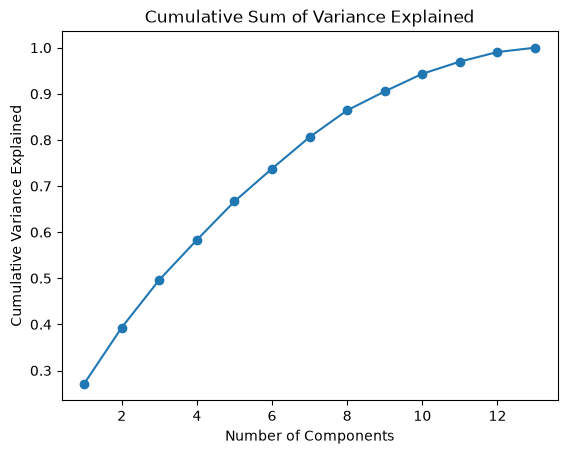

In [22]:

# Cumulative Sum of Variance Explained
cum_sum = np.cumsum(explained_var)
plt.figure()
plt.plot(np.arange(1, len(explained_var)+1), cum_sum, marker='o')
plt.title("Cumulative Sum of Variance Explained")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.show()


##Final PCA with k=10

In [23]:
# Final PCA with k=10 for compact song representations
music_pipe_final = Pipeline(stages=[
    VectorAssembler(inputCols=pca_features, outputCol='audio_features', handleInvalid='skip'),
    StandardScaler(withMean=True, withStd=True, inputCol='audio_features', outputCol='scaled_audio_features'),
    PCA(k=10, inputCol='scaled_audio_features', outputCol='pca_score')
])

music_model_final = music_pipe_final.fit(music_with_id_df)
music_pca_final = music_model_final.transform(music_with_id_df).cache()
print('Sum of Explained Variance with k=10:', sum(music_model_final.stages[-1].explainedVariance))
music_pca_final.select('id', 'name', 'artists', 'pca_score').show(5, truncate=False)


Sum of Explained Variance with k=10: 0.9433904133622065


+----------------------+---------------------------------------------+----------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|id                    |name                                         |artists                                 |pca_score                                                                                                                                                                                                 |
+----------------------+---------------------------------------------+----------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|6KbQ3uYMLKb5jDxLF7wYDD|Singende Bataillone 1. Teil    

##Recommendation System Based on PCA

In [24]:
# Recommendation system based on PCA vectors with exact, refined, and ambiguous lookup handling
def l2_dist(c1, c2):
    return float(np.sqrt((c1 - c2).T.dot((c1 - c2))))


def find_seed_tracks(df, track_id=None, song_name=None, artist_name=None, limit=10):
    if not any([track_id, song_name, artist_name]):
        raise ValueError('Provide track_id, song_name, or artist_name.')

    query = df
    if track_id is not None:
        query = query.where(fn.col('id') == track_id)
    if song_name is not None:
        query = query.where(fn.lower(fn.col('name')) == song_name.lower())
    if artist_name is not None:
        query = query.where(fn.lower(fn.col('artists')).contains(artist_name.lower()))

    return query.select('id', 'name', 'artists', 'popularity', 'year').limit(limit).toPandas()


def get_nearest_songs(song_name=None, num_nearest_songs=5, track_id=None, artist_name=None):
    candidates = find_seed_tracks(
        music_pca_final,
        track_id=track_id,
        song_name=song_name,
        artist_name=artist_name,
        limit=num_nearest_songs + 1,
    )

    if candidates.empty:
        return pd.DataFrame([{'status': 'not_found', 'message': 'No matching song was found. Try track_id, song_name, or artist_name.'}])
    if len(candidates) > 1:
        candidates.insert(0, 'status', 'ambiguous')
        return candidates

    seed_id = candidates.iloc[0]['id']
    song_df = (
        music_pca_final
        .where(fn.col('id') == seed_id)
        .select(fn.col('pca_score').alias('song_scores'))
        .join(music_pca_final)
        .where(fn.col('id') != seed_id)
        .withColumn('pca_array', vector_to_array('pca_score'))
        .withColumn('seed_array', vector_to_array('song_scores'))
        .withColumn(
            'dist',
            fn.expr(
                "sqrt(aggregate(zip_with(pca_array, seed_array, "
                "(x, y) -> pow(x - y, 2D)), 0D, (acc, x) -> acc + x))"
            ),
        )
        .orderBy(fn.asc('dist'))
        .select('id', 'name', 'artists', 'popularity', 'year', 'dist')
        .limit(num_nearest_songs)
    )

    result = song_df.toPandas()
    result.insert(0, 'status', 'ok')
    return result

# Example usage. Add artist_name or track_id if the song title is ambiguous.
get_nearest_songs(song_name='Sad Forever', num_nearest_songs=5)


,status,id,name,artists,popularity,year,dist
0,ok,4bBEH5gGRHf5YxZGqzIvMP,Foolish Pride,['Travis Tritt'],39.0,1995.0,0.293609
1,ok,1urmwhtXPiakhcqvqUi3rp,Brown Eyes,"""[""""Destiny's Child""""]""",61.0,2001.0,0.363704
2,ok,0bz0nJ3SztnFRKfSwFbhC6,My Everything,['98º'],49.0,2000.0,0.402675
3,ok,2vwlzO0Qp8kfEtzTsCXfyE,Wrecking Ball,['Miley Cyrus'],75.0,2013.0,0.467074
4,ok,7LQyaNDtdmUGnaQYmL3xZu,Pink Bullets,['The Shins'],48.0,2003.0,0.470193


##K-Means Clustering
Optimal Number of Clusters (Silhouette Score)

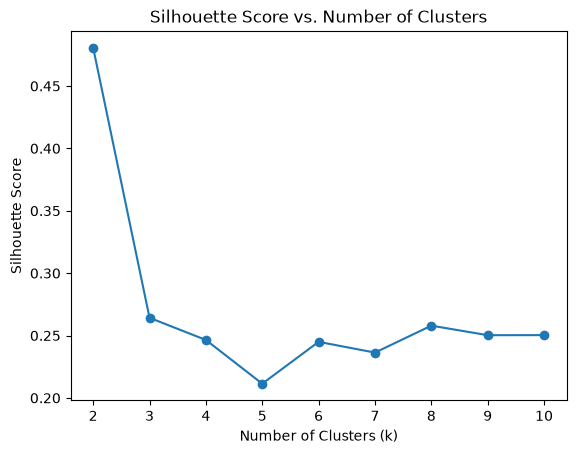

Optimal k: 2


In [25]:
# Find optimal K using scaled/PCA features instead of raw feature ranges
cluster_df = music_pca_final.select('id', 'name', 'artists', fn.col('pca_score').alias('features')).cache()

def optimal_k(df_in, k_min, k_max):
    silhouette_scores = []
    k_values = list(range(k_min, k_max + 1))
    evaluator = ClusteringEvaluator(featuresCol='features', predictionCol='prediction')

    for k in k_values:
        kmeans = KMeans(k=k, seed=42, featuresCol='features')
        model = kmeans.fit(df_in)
        predictions = model.transform(df_in)
        silhouette_scores.append(evaluator.evaluate(predictions))

    return k_values, silhouette_scores

k_values, silhouette_scores = optimal_k(cluster_df, k_min=2, k_max=10)

plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.show()

optimal_k_value = k_values[int(np.argmax(silhouette_scores))]
print('Optimal k:', optimal_k_value)


##Final K-Means Model

In [26]:
# Fit K-Means on PCA feature vectors
music_kmeans_model = KMeans(k=optimal_k_value, seed=42, featuresCol='features').fit(cluster_df)
music_kmeans = music_kmeans_model.transform(cluster_df).cache()

music_kmeans.select('name', 'artists', 'prediction').show()

evaluator = ClusteringEvaluator(featuresCol='features', predictionCol='prediction')
silhouette_score = evaluator.evaluate(music_kmeans)
print('Silhouette Score for K-Means:', silhouette_score)

freq_cluster = music_kmeans.groupby('prediction').count()
freq_cluster.orderBy('prediction').show()


+--------------------+--------------------+----------+
|                name|             artists|prediction|
+--------------------+--------------------+----------+
|Singende Bataillo...| ['Carl Woitschach']|         1|
|Fantasiestücke, O...|['Robert Schumann...|         1|
|Chapter 1.18 - Za...|['Seweryn Goszczy...|         0|
|Bebamos Juntos - ...|['Francisco Canaro']|         1|
|Polonaise-Fantais...|['Frédéric Chopin...|         1|
|Scherzo a capricc...|['Felix Mendelsso...|         1|
|Valse oubliée No....|['Franz Liszt', '...|         1|
| Per aspera ad astra| ['Carl Woitschach']|         1|
|Moneda Corriente ...|['Francisco Canar...|         1|
|Chapter 1.3 - Zam...|['Seweryn Goszczy...|         0|
|Piano Sonata No. ...|['Sergei Rachmani...|         1|
|Piano Sonata No. ...|['Frédéric Chopin...|         1|
|Piano Sonata in E...|['Samuel Barber',...|         1|
|Nachtstücke, Op. ...|['Robert Schumann...|         1|
|Symphony No. 5 in...|['Ludwig van Beet...|         1|
|A Shropsh

Silhouette Score for K-Means: 0.4807095639974681


+----------+------+
|prediction| count|
+----------+------+
|         0| 16255|
|         1|152207|
+----------+------+

